In [3]:
import math
class Value:
    def __init__(self,data,_children=(),_op="",label=""):
        self.data=data
        self.grad=0.0
        self._backward=lambda:None
        self._prev=set(_children)
        self._op=_op
        self.label=label
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data+other.data,(self,other),"+")
        def _backward():
            self.grad += 1.0* out.grad
            other.grad += 1.0* out.grad
        out._backward= _backward
        return out
    def __mul__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data*other.data,(self,other),"*")
        def _backward():
            self.grad +=other.data*out.grad
            other.grad += self.data*out.grad
        out._backward= _backward
        return out
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward
        return out

    def __rmul__(self,other):
        return self*other

    def __truediv__(self,other):
        return self*other**-1
    def __neg__(self): #-self
        return self * -1
    def __sub__(self, other): # self - other
        return self + (-other)

    def tanh(self):
        x=self.data
        t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out= Value(t,(self,),"tanh")
        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward= _backward
        return out
    def exp(self): #x.exp()= e^x
        x=self.data
        out=Value(math.exp(x),(self,),"exp")
        def _backward():
            self.grad=out.data*out.grad
        out._backward= _backward
        return out
        
    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

In [4]:
a=Value(2.0,label="a")
b=Value(-3.0,label="b")
c=Value(10.0,label="c")
e=a*b; e.label="e"
d=e+c; d.label="d"
f=Value(-2.0, label="f")
L=d*f; L.label="L"
print(L)

Value(data=-8.0)


In [5]:
from graphviz import Digraph

def trace(root):
    nodes,edges= set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot=Digraph(format="svg",graph_attr={"rankdir":"LR"})
    nodes,edges=trace(root)
    for n in nodes:
        uid=str(id(n))
        dot.node(name=uid,label= "{ %s | data %.4f | grad %.4f }" % (n.label,n.data,n.grad),shape="record")
        if n._op:
            dot.node(name=uid+n._op,label=n._op)
            dot.edge(uid+n._op,uid)
    for n1,n2 in edges:
        dot.edge(str(id(n1)),str(id(n2))+n2._op)
    return dot

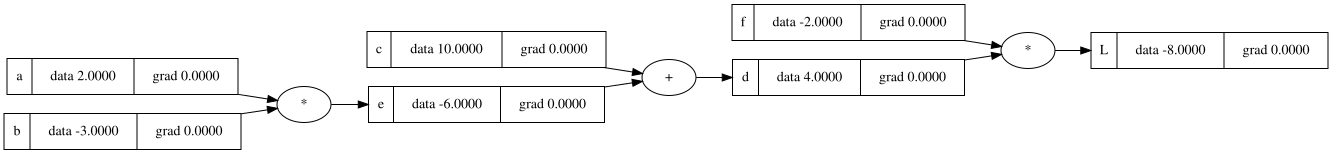

In [6]:
draw_dot(L)

We could check grad above by the following lol()

In [7]:
def lol():
    h=0.001
    
    a=Value(2.0,label="a")
    b=Value(-3.0,label="b")
    c=Value(10.0,label="c")
    e=a*b; e.label="e"
    d=e+c; d.label="d"
    f=Value(-2.0, label="f")
    L=d*f; L.label="L"
    L1= L.data
    
    a=Value(2.0,label="a")
    b=Value(-3.0,label="b")
    c=Value(10.0,label="c")
    e=a*b; e.label="e"
    d=e+c; d.label="d"
    f=Value(-2.0, label="f")
    L=d*f; L.label="L"
    L2= L.data
    print ((L2-L1)/h)

In [8]:
lol()

0.0


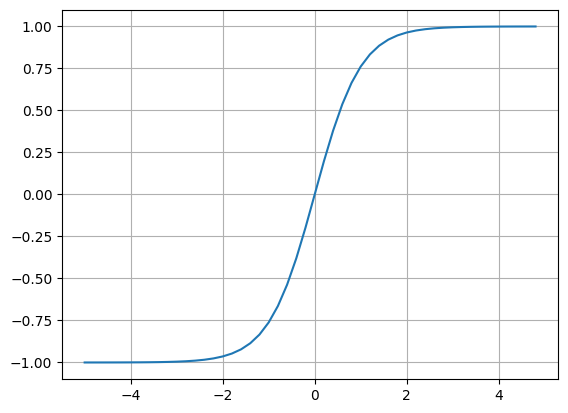

In [9]:
import matplotlib.pyplot as plt
import numpy as np
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)));plt.grid();

In [10]:
# input x1,x2
x1=Value(2.0, label="x1")
x2=Value(0.0, label="x2")
# weight w1,w2
w1=Value(-3.0, label="w1")
w2=Value(1.0, label="w2")
# bias of the neuron
b=Value(6.8813735870195432, label="b")
# x1*w1+x2*w2+b
x1w1= x1*w1; x1w1.label="x1*w1"
x2w2= x2*w2; x2w2.label="x2*w2"
x1w1x2w2=x1*w1+x2*w2; x1w1x2w2.label="x1w1+x2w2"
n= x1w1x2w2+b;n.label="n"
o= n.tanh(); o.label="o"

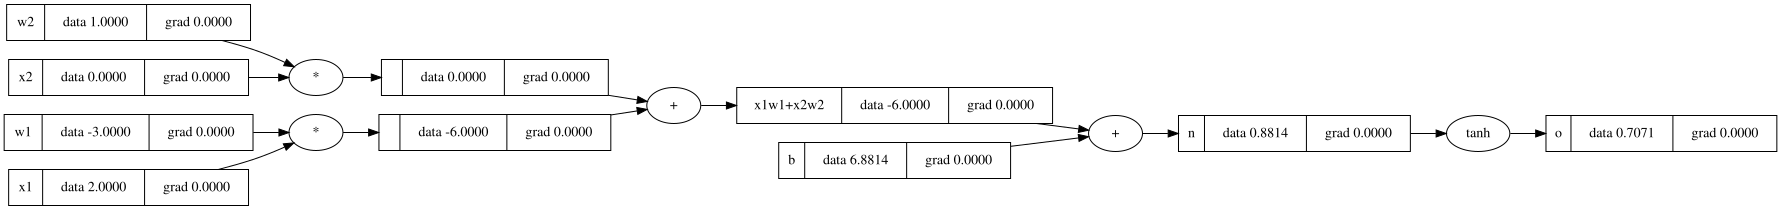

In [11]:
draw_dot(o)

o= tanh(n)
do/dn= 1- o**2

In [12]:
o.backward()

In [13]:
o.grad=1.0

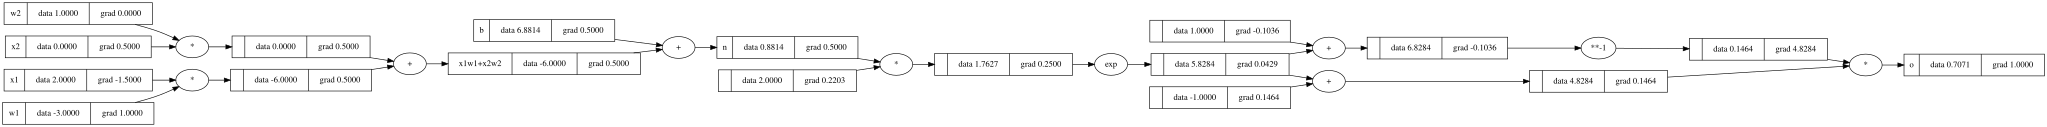

In [14]:
# input x1,x2
x1=Value(2.0, label="x1")
x2=Value(0.0, label="x2")
# weight w1,w2
w1=Value(-3.0, label="w1")
w2=Value(1.0, label="w2")
# bias of the neuron
b=Value(6.8813735870195432, label="b")
# x1*w1+x2*w2+b
x1w1= x1*w1; x1w1.label="x1*w1"
x2w2= x2*w2; x2w2.label="x2*w2"
x1w1x2w2=x1*w1+x2*w2; x1w1x2w2.label="x1w1+x2w2"
n= x1w1x2w2+b;n.label="n"
#-------------
e=(2*n).exp()
o=(e-1)/(e+1)
#-------------
o.label="o"
o.backward()
draw_dot(o)

In [15]:
import torch

In [16]:
torch.Tensor([[1,2,3],[4,5,6]]).shape

torch.Size([2, 3])

In [17]:
x1 = torch.Tensor([2.0]).double()
x2 = torch.Tensor([0.0]).double()
w1 = torch.Tensor([-3.0]).double()
w2 = torch.Tensor([1.0]).double()
b = torch.Tensor([6.8813735870195432]).double()

x1.requires_grad = True
x2.requires_grad = True
w1.requires_grad = True
w2.requires_grad = True
b.requires_grad = True

n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('———')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())


0.7071066904050358
———
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [18]:
import random

In [19]:
import random
from micrograd.engine import Value

class Module:

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self):
        return []

class Neuron(Module):

    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"

class Layer(Module):

    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"

class MLP(Module):

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], nonlin=i!=len(nouts)-1) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"